# A. Import Libraries

In [1]:
# Important Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.patches as patches

# B. Data Loading

Dataset: Superstore Sales Dataset

Source: Kaggle (https://kaggle.com/datasets/rohitsahoo/sales-forecasting/data)

Description: Retail dataset of a global superstore for 4 years (2015-2018).

In [12]:
# Load the dataset
df = pd.read_csv('D:\\DataKnowledges\\Data_Analytics\\Sales-Data-Analysis\\data\\processed\\cleaned_data.csv')

# C. Data Understanding

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9799 entries, 0 to 9798
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9799 non-null   str    
 1   Order Date     9799 non-null   str    
 2   Ship Date      9799 non-null   str    
 3   Ship Mode      9799 non-null   str    
 4   Customer ID    9799 non-null   str    
 5   Customer Name  9799 non-null   str    
 6   Segment        9799 non-null   str    
 7   Country        9799 non-null   str    
 8   City           9799 non-null   str    
 9   State          9799 non-null   str    
 10  Postal Code    9799 non-null   int64  
 11  Region         9799 non-null   str    
 12  Product ID     9799 non-null   str    
 13  Category       9799 non-null   str    
 14  Sub-Category   9799 non-null   str    
 15  Product Name   9799 non-null   str    
 16  Sales          9799 non-null   float64
dtypes: float64(1), int64(1), str(15)
memory usage: 1.3 MB


In [14]:
# What are the categories in this retail business?
print(df['Category'].unique())

<StringArray>
['Office Supplies', 'Technology', 'Furniture']
Length: 3, dtype: str


# D. Data Preprocessing

In [15]:
# Change the data type for 'Order Date' and 'Ship Date' into datetime

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [16]:
# dataset for yearly analysis
df['year'] = df['Order Date'].dt.year
df['quarter'] = df['Order Date'].dt.quarter


In [17]:
COLORS = ['#BC243C', '#4A90D9', '#FE840E']  # Technology, Furniture, Office Supplies
EXPLODE = (0.03, 0.03, 0.03)
CATEGORIES = ['Technology', 'Furniture', 'Office Supplies']

# E. Overview

In [18]:
def donut_chart(values, labels, title, center_label):
  # Reusable donut chart function.
  def autopct(pct):
    val = int(round(pct * np.sum(values) / 100))
    return f'{val:,}\n({pct:.1f}%)'

  fig, ax = plt.subplots(figsize=(10,8))
  ax.pie(
      values, colors=COLORS, labels=None, autopct=autopct,
      pctdistance=1.18, startangle=90, explode=EXPLODE
  )
  ax.add_artist(plt.Circle((0, 0), 0.7, fc='white'))
  ax.legend(labels, loc='lower right')
  ax.axis('equal')
  ax.annotate(center_label, xy=(0,0), fontsize=11, ha='center',
              color='#BC243C', fontweight='bold')
  plt.title(title, fontsize=14, fontweight='bold', pad=20)
  plt.tight_layout()
  plt.show( )

## E1. Sales by Category

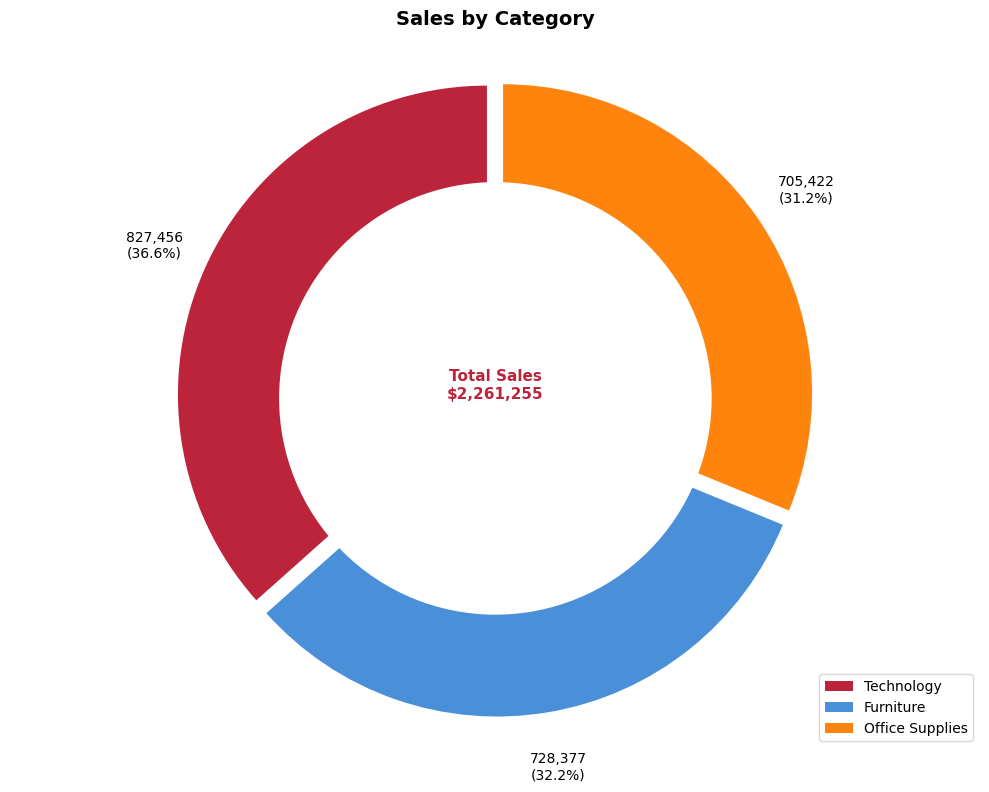

In [ ]:
sales = df.drop(['Order Date', 'Ship Date'], axis=1).groupby('Category')['Sales'].sum().reindex(CATEGORIES)

donut_chart(values=sales.values, labels=CATEGORIES, title='Sales by Category', center_label=f'Total Sales\n${sales.sum():,.0f}')

## E2. Orders by Category

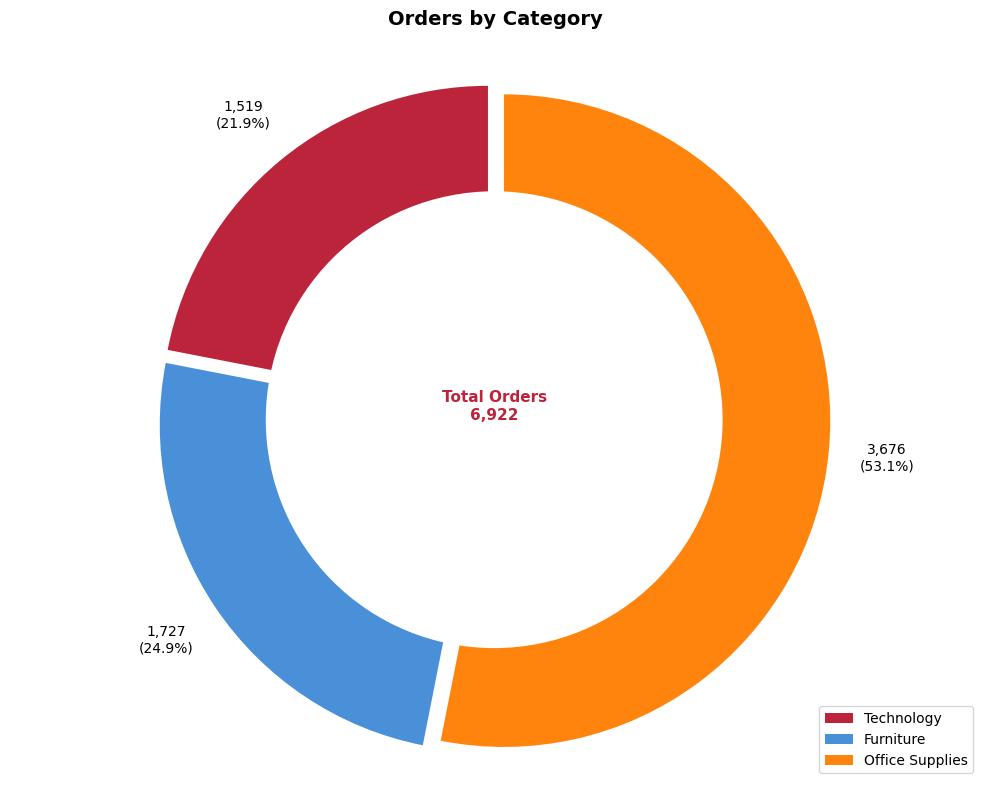

In [20]:
orders = df.groupby('Category')['Order ID'].nunique().reindex(CATEGORIES)

donut_chart(orders.values, CATEGORIES, 'Orders by Category', f'Total Orders\n{orders.sum():,}')

## E3. Customers by Category

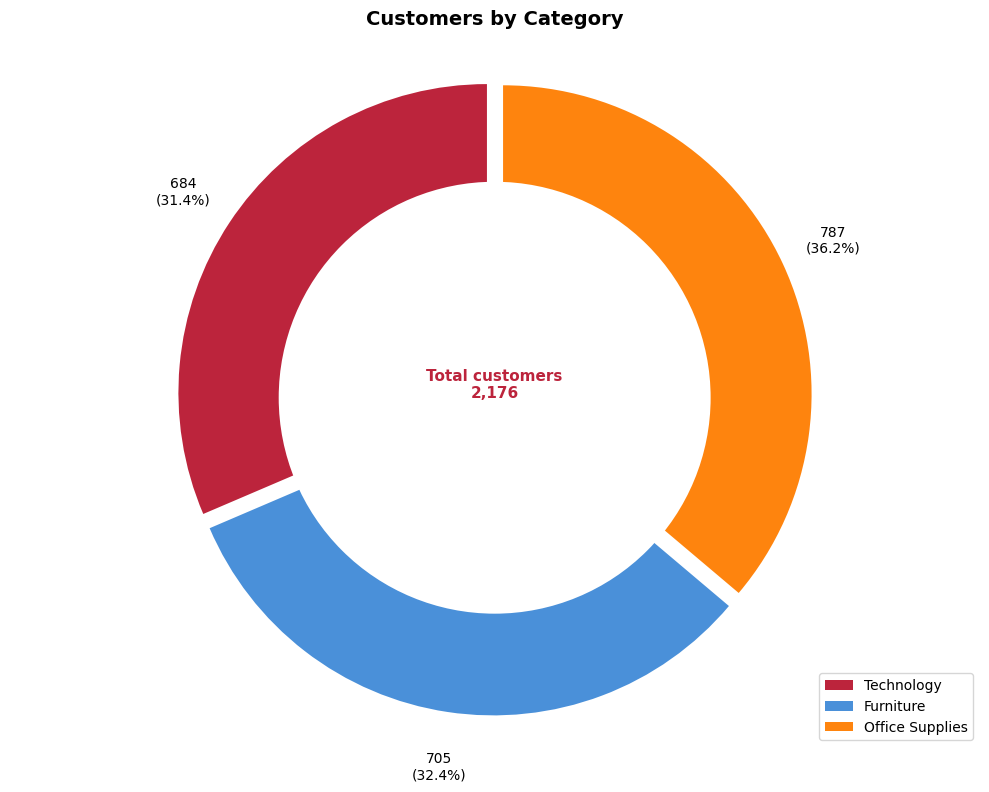

In [21]:
customers = df.groupby('Category')['Customer ID'].nunique().reindex(CATEGORIES)

donut_chart(customers.values, CATEGORIES, 'Customers by Category', f'Total customers\n{customers.sum():,}')

# F. Yearly Analysis

## F1. Sales per Year

In [22]:
sales_yearly = (
    df.groupby(['Category', 'year'])['Sales']
    .sum()
    .reset_index()
    .sort_values(by='year')
)

In [23]:
# Per-category annotation offsets to avoid overlap
OFFSETS = {
    'Technology'     : (0, -15),   # always below
    'Furniture'      : (0,  18),   # always above
    'Office Supplies': (0,  10),   # always above
}

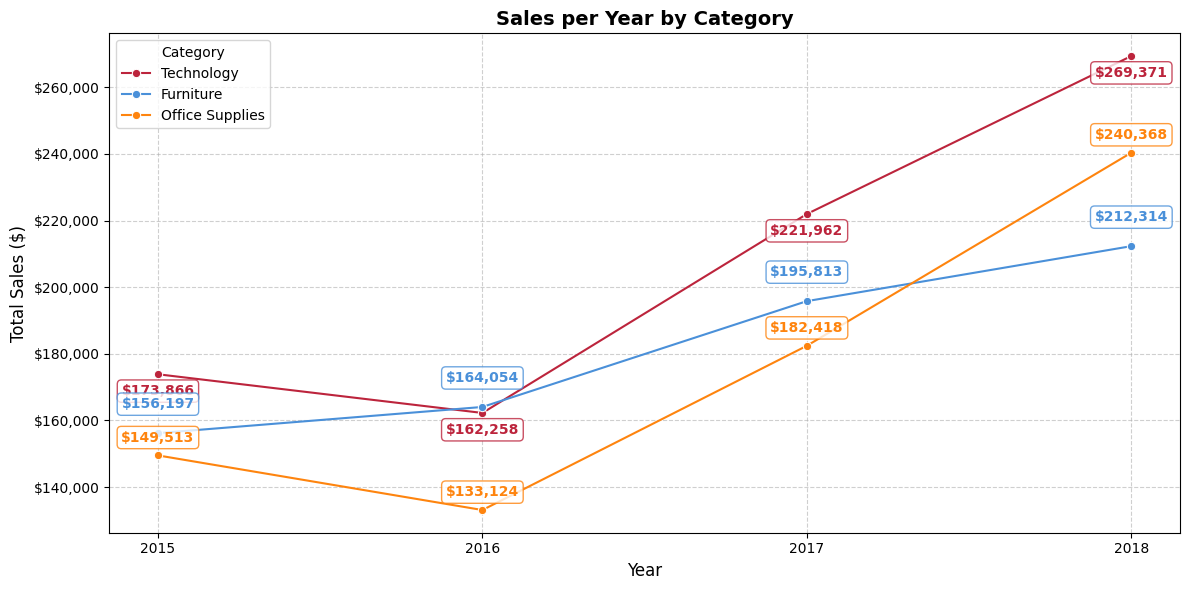

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))

for category, color in zip(CATEGORIES, COLORS):
  data = sales_yearly[sales_yearly['Category'] == category]
  sns.lineplot(
      data=data, x='year', y='Sales',
      label=category, color=color,
      marker='o', ax=ax
  )

  for _, row in data.iterrows():
    ax.annotate(
        f"${row['Sales']:,.0f}",
        xy=(row['year'], row['Sales']),
        xytext=OFFSETS[category],
        textcoords='offset points',
        color=color, ha='center', fontsize=10,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color, lw=1, alpha=0.8)
    )

plt.title('Sales per Year by Category', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(sales_yearly['year'].unique())
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
plt.legend(title='Category')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## F2. YoY Sales Growth

In [25]:
sales_yearly['YoY Growth'] = (
    sales_yearly.groupby('Category')['Sales'].pct_change() * 100
)

yoy = sales_yearly.dropna(subset=['YoY Growth'])
years = sorted(yoy['year'].unique())
x = np.arange(len(years))
width = 0.25 # width for each bar

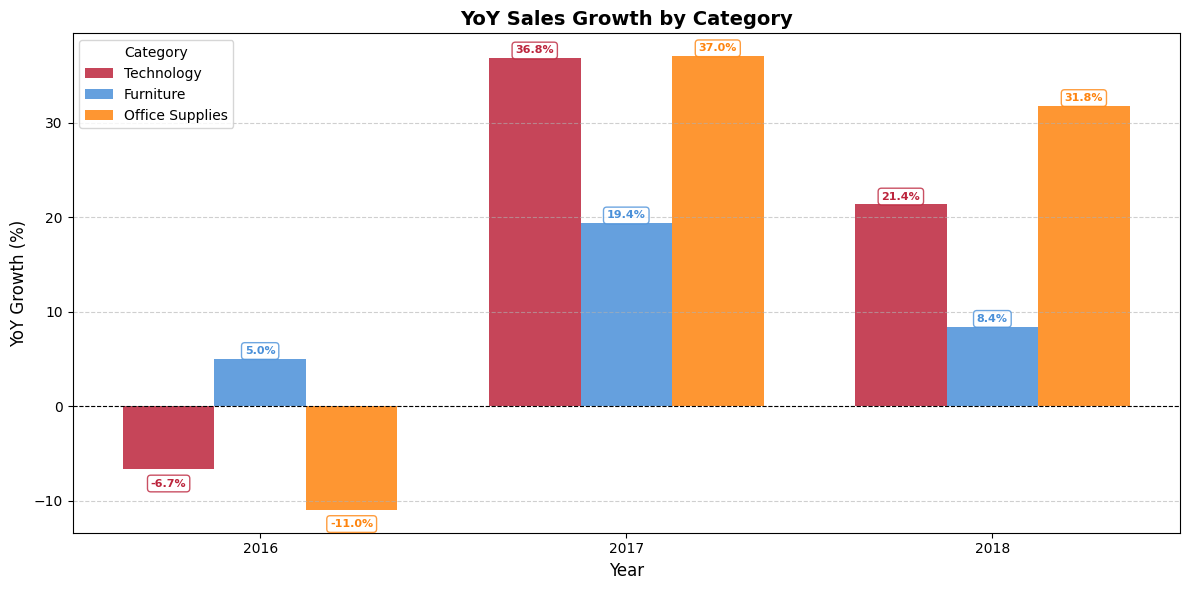

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

for i, (category, color) in enumerate(zip(CATEGORIES, COLORS)):
  data = yoy[yoy['Category'] == category]
  bars = ax.bar(
      x + i * width, data['YoY Growth'],
      width=width, color=color,
      label=category, alpha=0.85
  )

  for bar, val in zip(bars, data['YoY Growth']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (0.5 if val >= 0 else -1.8),
        f'{val:.1f}%',
        ha='center', fontsize=8, fontweight='bold', color=color,
        bbox=dict(boxstyle='round,pad=0.3', fc='white',
                  ec=color, lw=1, alpha=0.8)
    )

ax.set_title('YoY Sales Growth by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('YoY Growth (%)', fontsize=12)
ax.set_xticks(x + width)
ax.set_xticklabels(years)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(title='Category')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## F3. CAGR Summary Table

In [27]:
cagr_summary = []

for category, color in zip(CATEGORIES, COLORS):
  data = sales_yearly[sales_yearly['Category'] == category].sort_values('year')
  bv = data['Sales'].iloc[0]
  ev = data['Sales'].iloc[-1]
  n = len(data) - 1
  cagr = ((ev / bv) ** (1 / n) - 1) * 100
  growth = ((ev - bv) / bv) * 100

  cagr_summary.append({
      'Category' : category,
      'Color': color,
      'Start Year' : int(data['year'].iloc[0]),
      'End Year' : int(data['year'].iloc[-1]),
      'Starting Sales' : bv,
      'Ending Sales' : ev,
      'Total Growth (%)' : f'{growth:.1f}%',
      'CAGR (%)' : f'{cagr:.1f}%'
  })

cagr_df = pd.DataFrame(cagr_summary)

In [28]:
cagr_df

,Category,Color,Start Year,End Year,Starting Sales,Ending Sales,Total Growth (%),CAGR (%)
0,Technology,#BC243C,2015,2018,173865.5070,269370.6910,54.9%,15.7%
1,Furniture,#4A90D9,2015,2018,156196.5091,212313.7872,35.9%,10.8%
2,Office Supplies,#FE840E,2015,2018,149512.8200,240367.5410,60.8%,17.1%


In [29]:
cagr_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Category          3 non-null      str    
 1   Color             3 non-null      str    
 2   Start Year        3 non-null      int64  
 3   End Year          3 non-null      int64  
 4   Starting Sales    3 non-null      float64
 5   Ending Sales      3 non-null      float64
 6   Total Growth (%)  3 non-null      str    
 7   CAGR (%)          3 non-null      str    
dtypes: float64(2), int64(2), str(4)
memory usage: 324.0 bytes


In [30]:
cagr_df['CAGR (%)'] = cagr_df['CAGR (%)'].str.replace('%', '').astype(float)

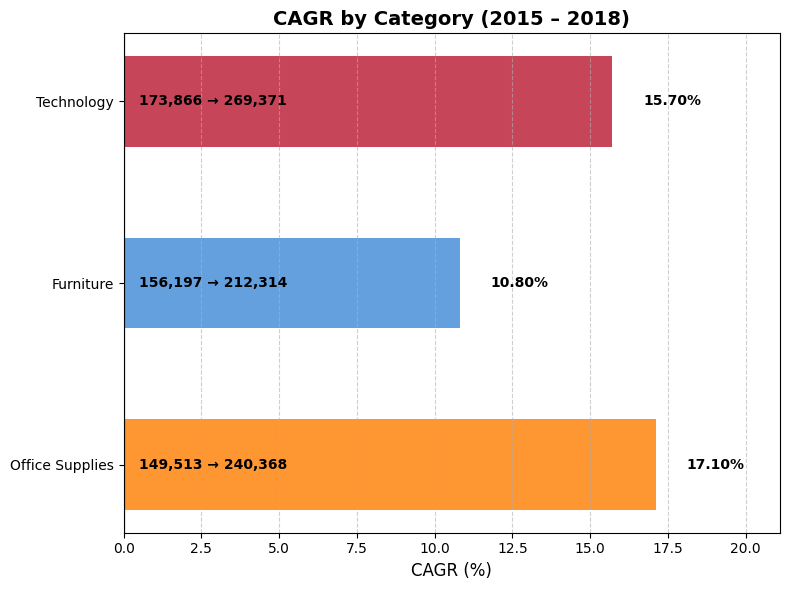

In [31]:
# CAGR Bar Chart
fig, ax = plt.subplots(figsize=(8,6))

bars = ax.barh(
    cagr_df['Category'],
    cagr_df['CAGR (%)'],
    color=cagr_df['Color'],
    alpha=0.85,
    height=0.5
)

# Data Labels
for bar, val in zip(bars, cagr_df['CAGR (%)']):
  ax.text(
      bar.get_width() + 1,
      bar.get_y() + bar.get_height() / 2,
      f'{val:.2f}%',
      va='center', fontsize=10, fontweight='bold'
  )

# Starting & Ending Sales annotations inside bars
for bar, row in zip(bars, cagr_df.itertuples()):
  ax.text(
      0.5,
      bar.get_y() + bar.get_height() / 2,
      f"{row._5:,.0f} → {row._6:,.0f}",
      va='center', fontsize=10, color='black',
      fontweight='bold'
  )

ax.set_title('CAGR by Category (2015 – 2018)', fontsize=14, fontweight='bold')
ax.set_xlabel('CAGR (%)', fontsize=12)
ax.set_xlim(0, cagr_df['CAGR (%)'].max() + 4)
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(True, axis='x', linestyle='--', alpha=0.6)
ax.invert_yaxis()  # Highest CAGR on top
plt.tight_layout()
plt.show()

In [32]:
# Clean display table
cagr_display = cagr_df.drop(columns='Color')
cagr_display['Starting Sales'] = cagr_display['Starting Sales'].apply(lambda x: f'${x:,.0f}')
cagr_display['Ending Sales'] = cagr_display['Ending Sales'].apply(lambda x: f'${x:,.0f}')
cagr_display['CAGR (%)'] = cagr_display['CAGR (%)'].apply(lambda x: f'{x:.2f}%')
cagr_display

,Category,Start Year,End Year,Starting Sales,Ending Sales,Total Growth (%),CAGR (%)
0,Technology,2015,2018,"$173,866","$269,371",54.9%,15.70%
1,Furniture,2015,2018,"$156,197","$212,314",35.9%,10.80%
2,Office Supplies,2015,2018,"$149,513","$240,368",60.8%,17.10%


## F4. Orders Per Year

In [33]:
orders_yearly = (
    df.groupby(['Category', 'year'])['Order ID']
    .nunique()
    .reset_index()
    .sort_values(by='year')
)

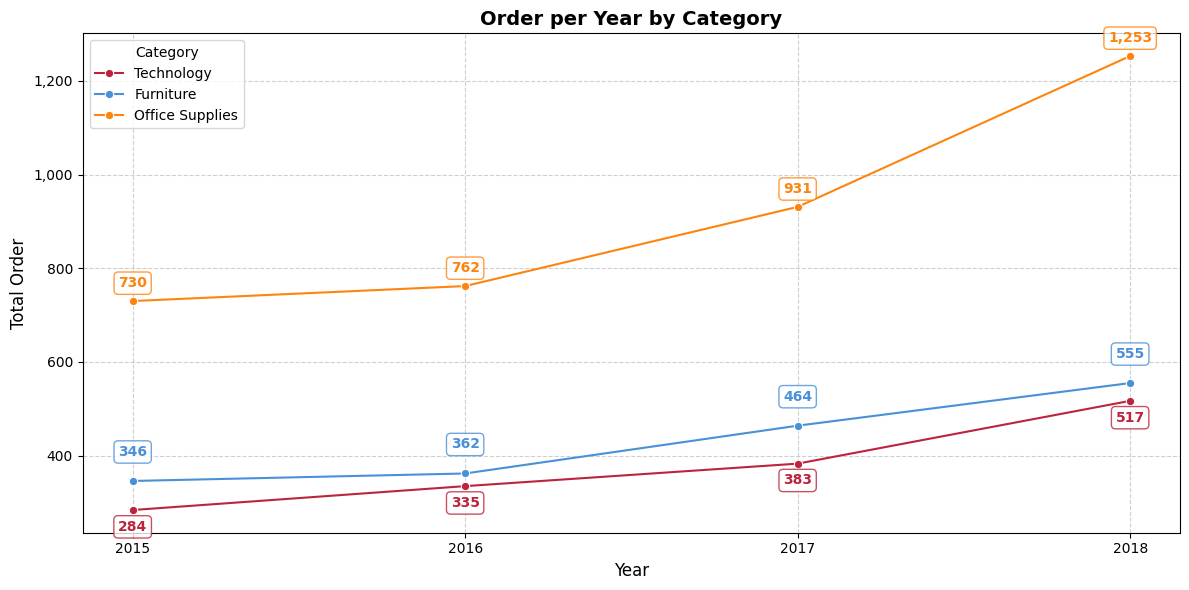

In [34]:
fig, ax = plt.subplots(figsize=(12, 6))

for category, color in zip(CATEGORIES, COLORS):
  data = orders_yearly[orders_yearly['Category'] == category]
  sns.lineplot(
      data=data, x='year', y='Order ID',
      label=category, color=color,
      marker='o', ax=ax
  )

  for _, row in data.iterrows():
    ax.annotate(
        f"{row['Order ID']:,.0f}",
        xy=(row['year'], row['Order ID']),
        xytext=OFFSETS[category],
        textcoords='offset points',
        color=color, ha='center', fontsize=10,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color, lw=1, alpha=0.8)
    )

plt.title('Order per Year by Category', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Order', fontsize=12)
plt.xticks(orders_yearly['year'].unique())
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.legend(title='Category')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## F5. Customers Per Year

In [35]:
customers_yearly = (
    df.groupby(['Category', 'year'])['Customer ID']
    .nunique()
    .reset_index()
    .sort_values(by='year')
)

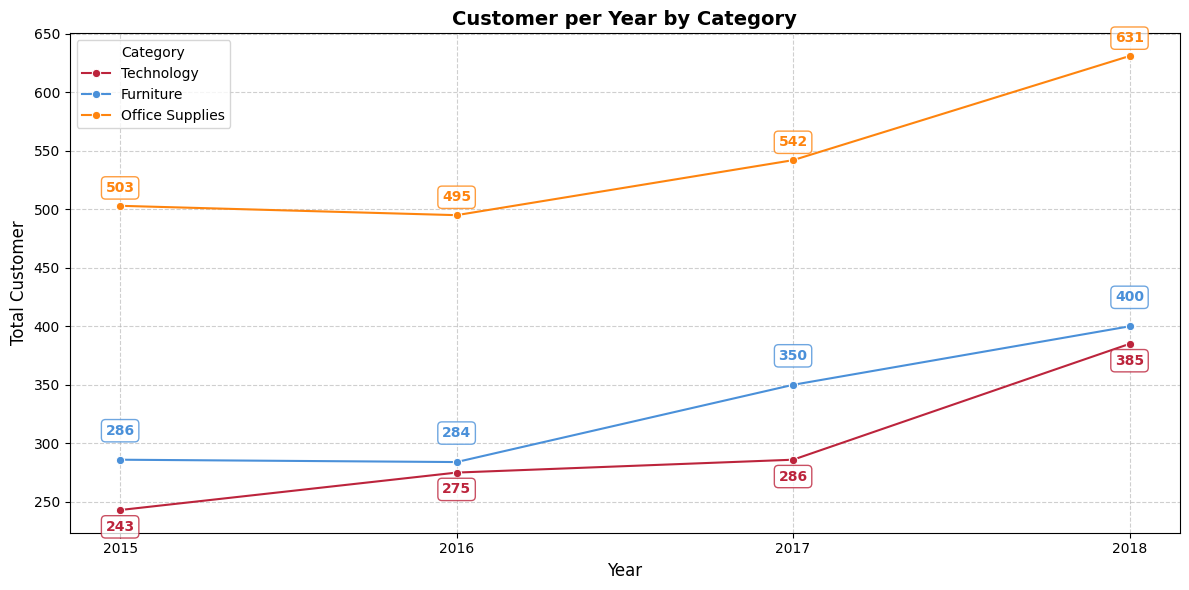

In [36]:
fig, ax = plt.subplots(figsize=(12, 6))

for category, color in zip(CATEGORIES, COLORS):
  data = customers_yearly[customers_yearly['Category'] == category]
  sns.lineplot(
      data=data, x='year', y='Customer ID',
      label=category, color=color,
      marker='o', ax=ax
  )

  for _, row in data.iterrows():
    ax.annotate(
        f"{row['Customer ID']:,.0f}",
        xy=(row['year'], row['Customer ID']),
        xytext=OFFSETS[category],
        textcoords='offset points',
        color=color, ha='center', fontsize=10,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color, lw=1, alpha=0.8)
    )

plt.title('Customer per Year by Category', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Customer', fontsize=12)
plt.xticks(customers_yearly['year'].unique())
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.legend(title='Category')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# G. Quarterly Analysis

In [37]:
# Precompute quarterly data (reused across F1, F2, F3)
df['quarter_label'] = df['Order Date'].dt.year.astype(str) + ' Q' + df['quarter'].astype(str)

In [38]:
sales_quarterly = (
    df.groupby(['Category', 'quarter_label'])['Sales']
    .sum()
    .reset_index()
    .sort_values(by='quarter_label')
)

orders_quarterly = (
    df.groupby(['Category', 'quarter_label'])['Order ID']
    .nunique()
    .reset_index()
    .sort_values(by='quarter_label')
)

customers_quarterly = (
    df.groupby(['Category', 'quarter_label'])['Customer ID']
    .nunique()
    .reset_index()
    .sort_values(by='quarter_label')
)

quarters = sales_quarterly['quarter_label'].unique()
x = np.arange(len(quarters))
width = 0.25

In [39]:
def bar_chart_quarter(quarterly_data, title, y_feature, ylabel, quarters):
    fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.01)

    is_sales = ylabel == 'Total Sales ($)'

    for ax, category, color in zip(axes, CATEGORIES, COLORS):
        data = quarterly_data[quarterly_data['Category'] == category].sort_values('quarter_label')

        sns.lineplot(data=data, x='quarter_label', y=y_feature,
                     marker='o', color=color, label=category, ax=ax)

        # Annotations
        for _, row in data.iterrows():
            label = f"${row[y_feature]:,.0f}" if is_sales else f"{int(row[y_feature]):,}"
            ax.annotate(
                label,
                xy=(row['quarter_label'], row[y_feature]),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=7.5, fontweight='bold', color=color,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color, lw=0.8, alpha=0.85)
            )

        ax.set_title(category, fontsize=12, fontweight='bold', color=color)
        ax.set_xlabel('')
        ax.set_ylabel(ylabel, fontsize=10)
        ax.legend().remove()
        ax.grid(True, linestyle='--', alpha=0.6)

        if is_sales:
            ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
        else:
            ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

    # Shared x-axis labels on the bottom subplot only
    axes[-1].set_xlabel('Quarter', fontsize=12)
    axes[-1].set_xticks(range(len(quarters)))
    axes[-1].set_xticklabels(quarters, rotation=45, ha='right', fontsize=9)

    plt.tight_layout()
    plt.show()

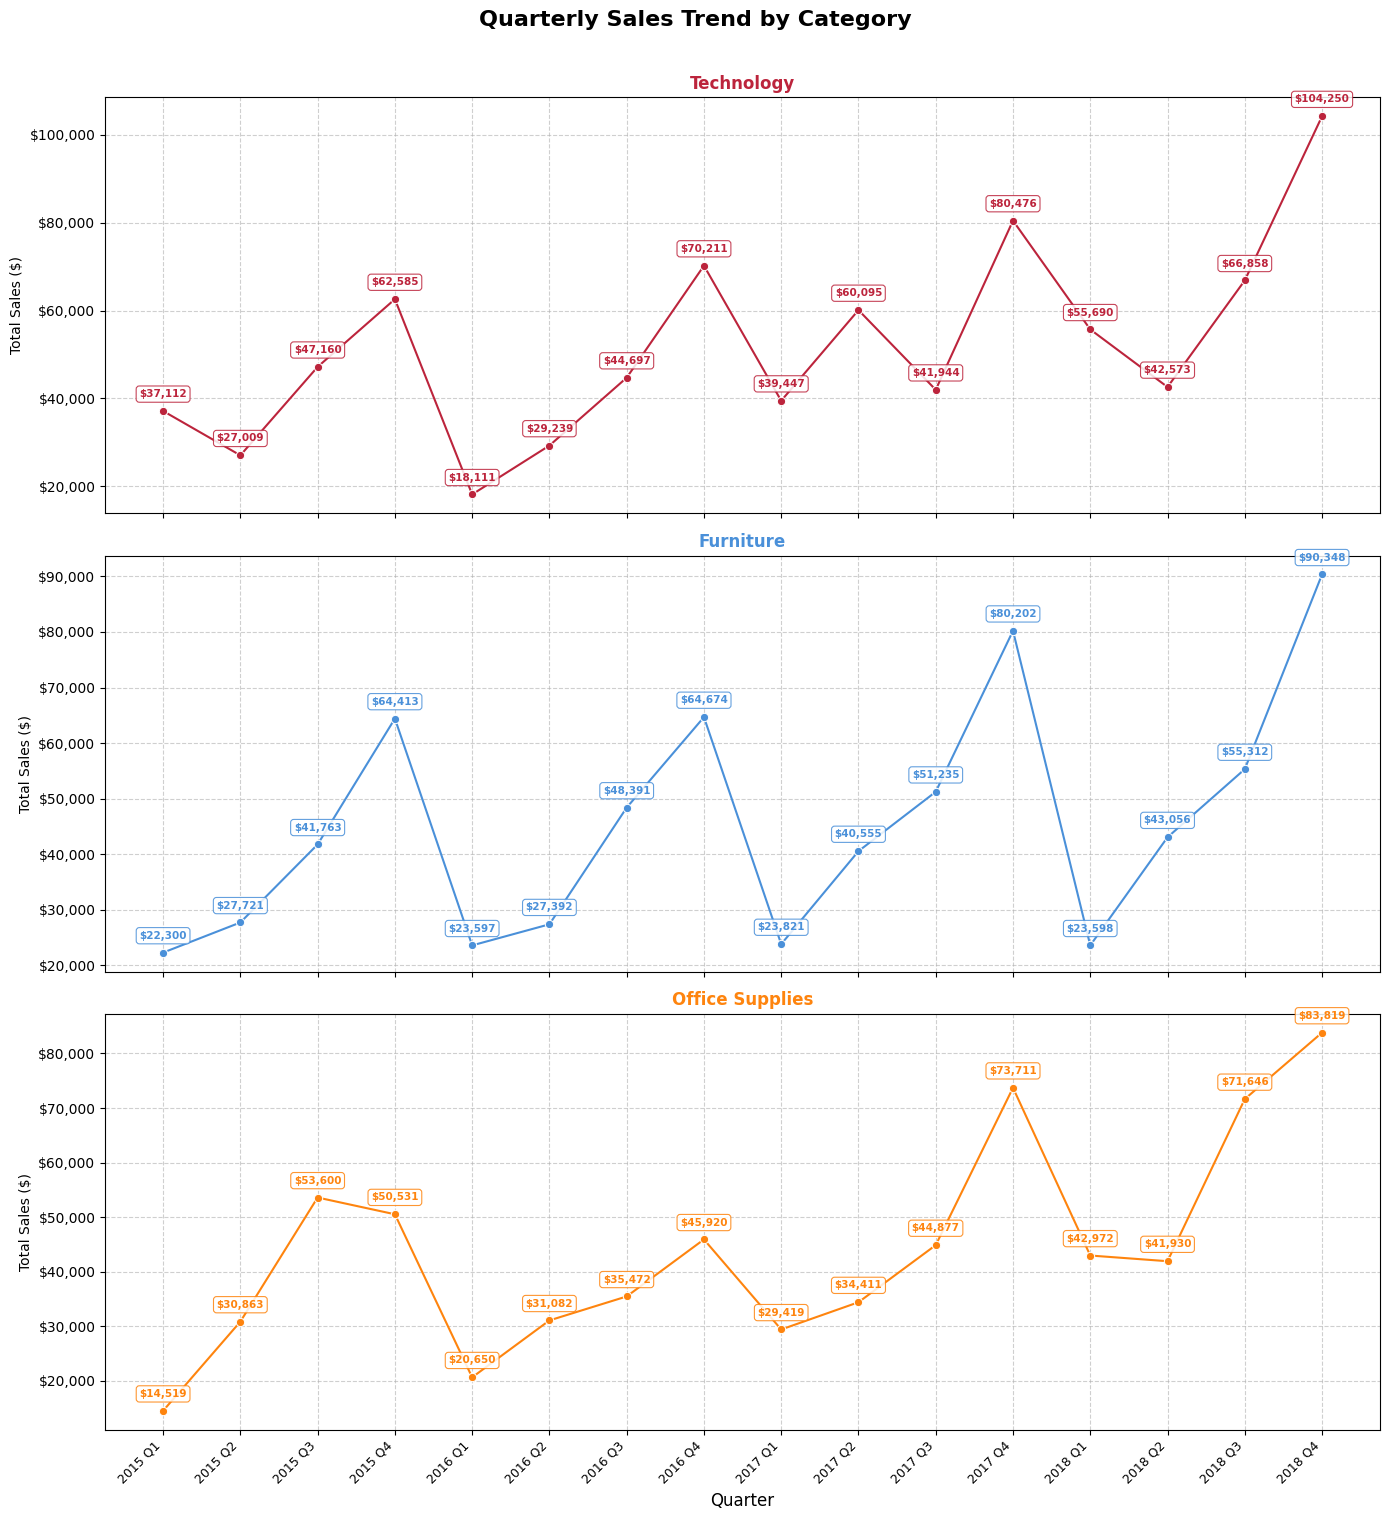

In [40]:
bar_chart_quarter(sales_quarterly, 'Quarterly Sales Trend by Category', 'Sales', 'Total Sales ($)', quarters)

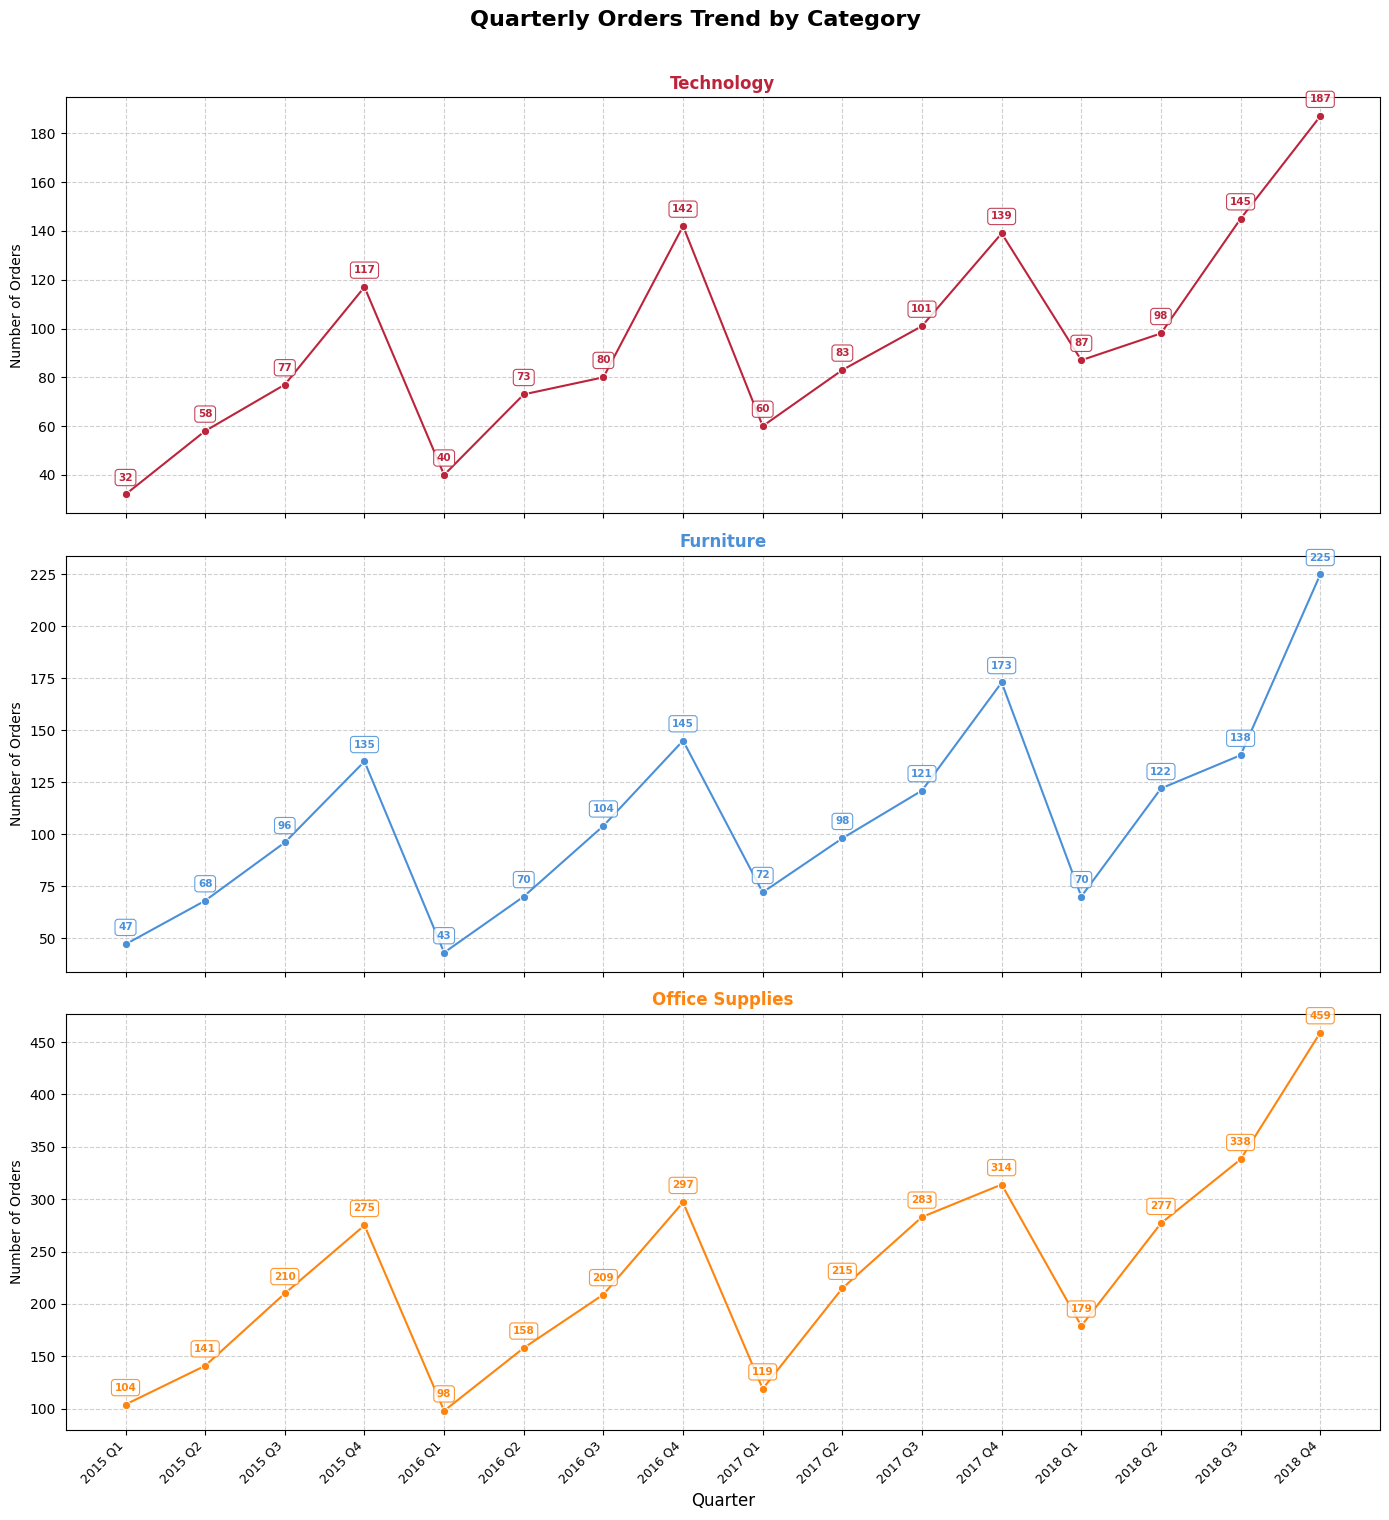

In [41]:
bar_chart_quarter(orders_quarterly, 'Quarterly Orders Trend by Category', 'Order ID', 'Number of Orders', quarters)

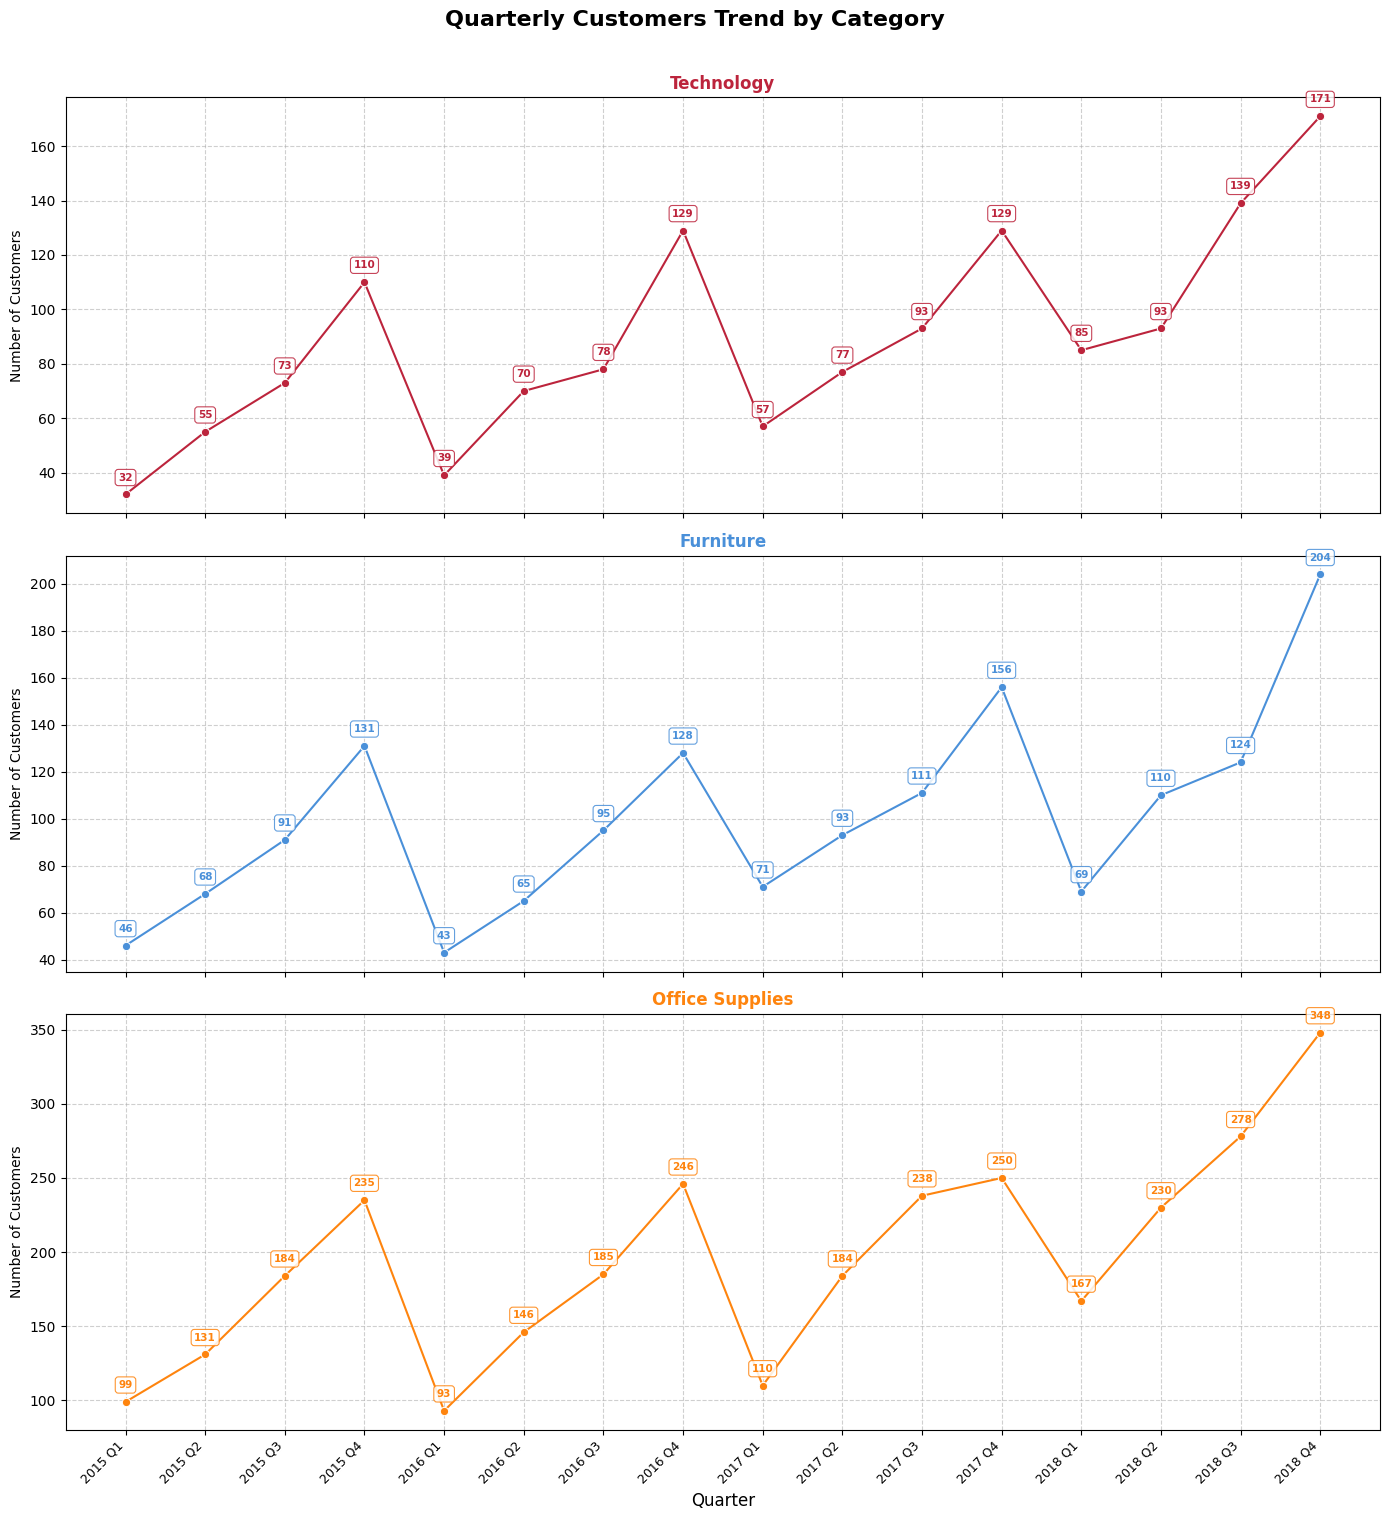

In [42]:
bar_chart_quarter(customers_quarterly, 'Quarterly Customers Trend by Category', 'Customer ID', 'Number of Customers', quarters)

# H. Summary & Recommendations

## H1. Key Findings

### Sales Performance
- **Technology** leads in total sales ($269,371) with a steady CAGR of 15.67%
- **Office Supplies** has the highest growth rate (CAGR 17.16%) despite starting lowest
- **Furniture** shows the slowest growth (CAGR 10.75%), lagging behind both categories

### Seasonal Pattern
- All three categories consistently peak in **Q4** every year — likely driven by end-of-year budget spending
- **Q1** is the weakest quarter across all categories — a recurring dip worth monitoring
- Technology shows the most volatile quarterly swings, while Office Supplies is the most stable


### Orders & Customers
- Office Supplies dominates in order volume and customer count despite lower sales per order
- Technology generates the highest sales per order — fewer orders, higher value
- Furniture has the lowest order volume, suggesting longer purchase cycles

## H2. Recommendations

| Priority | Goal | Action |
|---|---|---|
| 1 | Capitalize on Q4 peak | Run targeted promotions ahead of the surge |
| 2 | Investigate Q1 dip | Consider off-season campaigns to stabilize sales |
| 3 | Grow Furniture | Low CAGR signals untapped potential or supply-side constraints |
| 4 | Upsell Office Supplies | High volume but low sales per order; bundling could help |

## H3. Summary Visualization

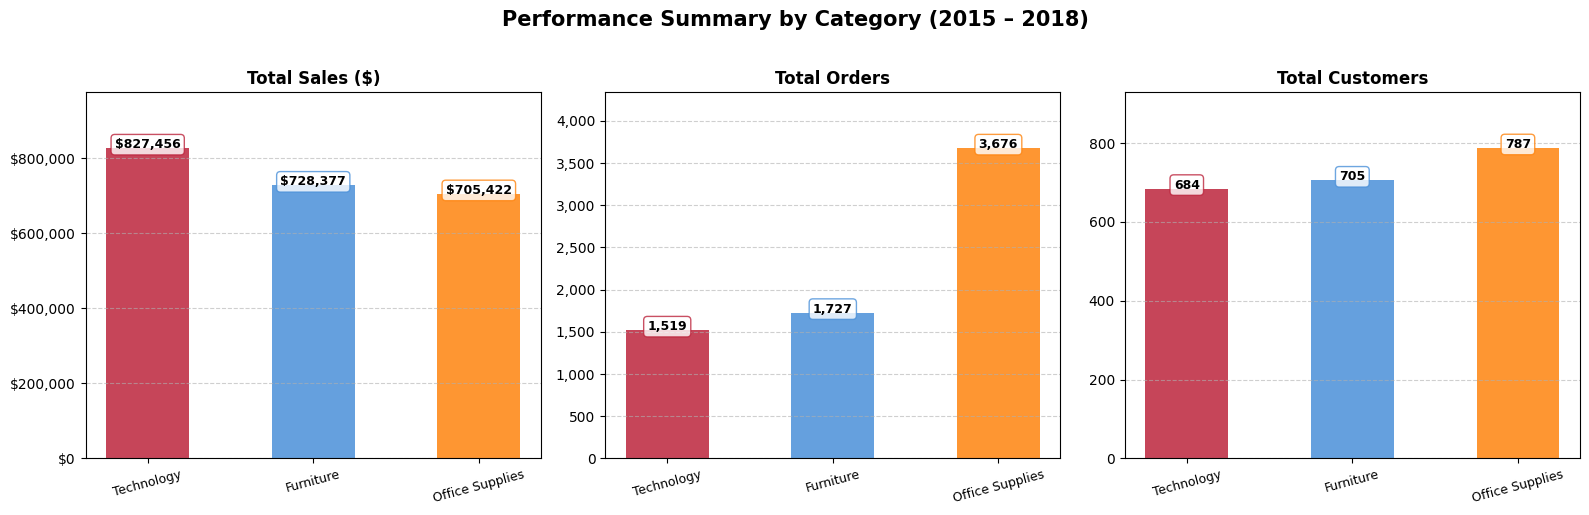

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
fig.suptitle('Performance Summary by Category (2015 – 2018)', fontsize=15, fontweight='bold', y=1.02)

metrics = [
    ('Total Sales ($)', sales),
    ('Total Orders', orders),
    ('Total Customers', customers)
]

for ax, (title, data) in zip(axes, metrics):
  bars = ax.bar(CATEGORIES, data.values, color=COLORS, alpha=0.85, width=0.5)

  # Data labels on top of each bar
  for i, (bar, val) in enumerate(zip(bars, data.values)):
    label = f'${val:,.0f}' if title == 'Total Sales ($)' else f'{val:,}'
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (0.5 if val >= 0 else -1.8),
        label, ha='center', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='white',
                  ec=COLORS[i], lw=1, alpha=0.8)
    )

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(CATEGORIES)))
    ax.set_xticklabels(CATEGORIES, rotation=15, ha='center', fontsize=9)
    ax.set_ylim(0, data.values.max() * 1.18)
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)

    if title == 'Total Sales ($)':
      ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
    else :
      ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()